# 02. Model Training — Distracted Driver Detection

**Model**: EfficientNetB0 (Transfer Learning from ImageNet)  
**Dataset**: State Farm Distracted Driver Detection (10 classes)  
**Strategy**: Fine-tune on training split, evaluate on validation split (subject-level, no leakage)

> Set `SAMPLE_MODE = True` để train nhanh với tập nhỏ (kiểm tra pipeline).  
> Set `SAMPLE_MODE = False` để train đầy đủ.

## 0. Config

In [22]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ─── Fix SSL Certificate Issues (macOS Python 3.13) ───────────────────────────
import ssl
import certifi
import urllib.request

# Create SSL context with certifi certificates
ssl_context = ssl.create_default_context(cafile=certifi.where())

# Monkey-patch urllib to use certifi certificates
opener = urllib.request.build_opener(
    urllib.request.HTTPSHandler(context=ssl_context)
)
urllib.request.install_opener(opener)

# Also set the default HTTPS context
ssl._create_default_https_context = lambda: ssl_context

# Suppress FutureWarning from keras/tensorflow about np.object
warnings.filterwarnings('ignore', category=FutureWarning, module='keras')

# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = '..'
DATA_DIR      = os.path.join(BASE_DIR, 'data', 'raw', 'statefarm')
IMG_DIR       = os.path.join(DATA_DIR, 'imgs', 'train')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# ─── Hyperparameters ───────────────────────────────────────────────────────────
SAMPLE_MODE   = True    # True = dùng tập nhỏ để kiểm tra pipeline nhanh
SAMPLE_PER_CLASS = 50   # Số ảnh/class khi SAMPLE_MODE = True

IMG_SIZE      = 224     # EfficientNetB0 input size
BATCH_SIZE    = 32
EPOCHS        = 20      # Max epochs (early stopping sẽ dừng sớm nếu cần)
LEARNING_RATE = 1e-3
NUM_CLASSES   = 10

CLASS_NAMES = [f'c{i}' for i in range(NUM_CLASSES)]
CLASS_LABELS = {
    'c0': 'Normal driving',
    'c1': 'Texting (right)',
    'c2': 'Phone (right)',
    'c3': 'Texting (left)',
    'c4': 'Phone (left)',
    'c5': 'Radio',
    'c6': 'Drinking',
    'c7': 'Reaching behind',
    'c8': 'Hair & makeup',
    'c9': 'Talking to passenger',
}

print(f'TensorFlow version : {tf.__version__}')
print(f'GPUs available     : {len(tf.config.list_physical_devices("GPU"))}')
print(f'Sample mode        : {SAMPLE_MODE}')
if SAMPLE_MODE:
    print(f'  => {SAMPLE_PER_CLASS} images/class  ({SAMPLE_PER_CLASS * NUM_CLASSES} total)')

TensorFlow version : 2.20.0
GPUs available     : 0
Sample mode        : True
  => 50 images/class  (500 total)


## 1. Load Metadata

In [23]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_metadata.csv'))
val_df   = pd.read_csv(os.path.join(PROCESSED_DIR, 'val_metadata.csv'))

print(f'Full train set : {len(train_df)} images')
print(f'Full val set   : {len(val_df)} images')

# ─── Sample nếu SAMPLE_MODE ────────────────────────────────────────────────────
if SAMPLE_MODE:
    # Sample per class using a more robust method to avoid FutureWarnings
    sampled_train = []
    for classname, group in train_df.groupby('classname'):
        sampled = group.sample(min(SAMPLE_PER_CLASS, len(group)), random_state=SEED)
        sampled_train.append(sampled)
    train_df = pd.concat(sampled_train, ignore_index=True)

    sampled_val = []
    for classname, group in val_df.groupby('classname'):
        sampled = group.sample(min(SAMPLE_PER_CLASS // 5, len(group)), random_state=SEED)
        sampled_val.append(sampled)
    val_df = pd.concat(sampled_val, ignore_index=True)

    print(f'\n[SAMPLE MODE] Sampled train : {len(train_df)} images')
    print(f'[SAMPLE MODE] Sampled val   : {len(val_df)} images')

# Tạo full image path
train_df['filepath'] = train_df.apply(
    lambda r: os.path.join(IMG_DIR, r['classname'], r['img']), axis=1
)
val_df['filepath'] = val_df.apply(
    lambda r: os.path.join(IMG_DIR, r['classname'], r['img']), axis=1
)

# Encode label thành integer
label2idx = {c: i for i, c in enumerate(sorted(CLASS_NAMES))}
train_df['label'] = train_df['classname'].map(label2idx)
val_df['label']   = val_df['classname'].map(label2idx)

print('\nClass distribution (train):')
print(train_df['classname'].value_counts().sort_index())

Full train set : 18899 images
Full val set   : 3525 images

[SAMPLE MODE] Sampled train : 500 images
[SAMPLE MODE] Sampled val   : 100 images

Class distribution (train):
classname
c0    50
c1    50
c2    50
c3    50
c4    50
c5    50
c6    50
c7    50
c8    50
c9    50
Name: count, dtype: int64


## 2. Build tf.data Pipeline

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    """Đọc ảnh từ đĩa, decode và resize."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Convert to float32 and normalize to [0, 1]
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment(img, label):
    """Data augmentation cho training set."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.image.random_saturation(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def make_dataset(df, training=False):
    filepaths = df['filepath'].values
    labels    = df['label'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)

print('Train batches :', len(train_ds))
print('Val batches   :', len(val_ds))

Train batches : 16
Val batches   : 4


## 3. Visualise Sample Batch

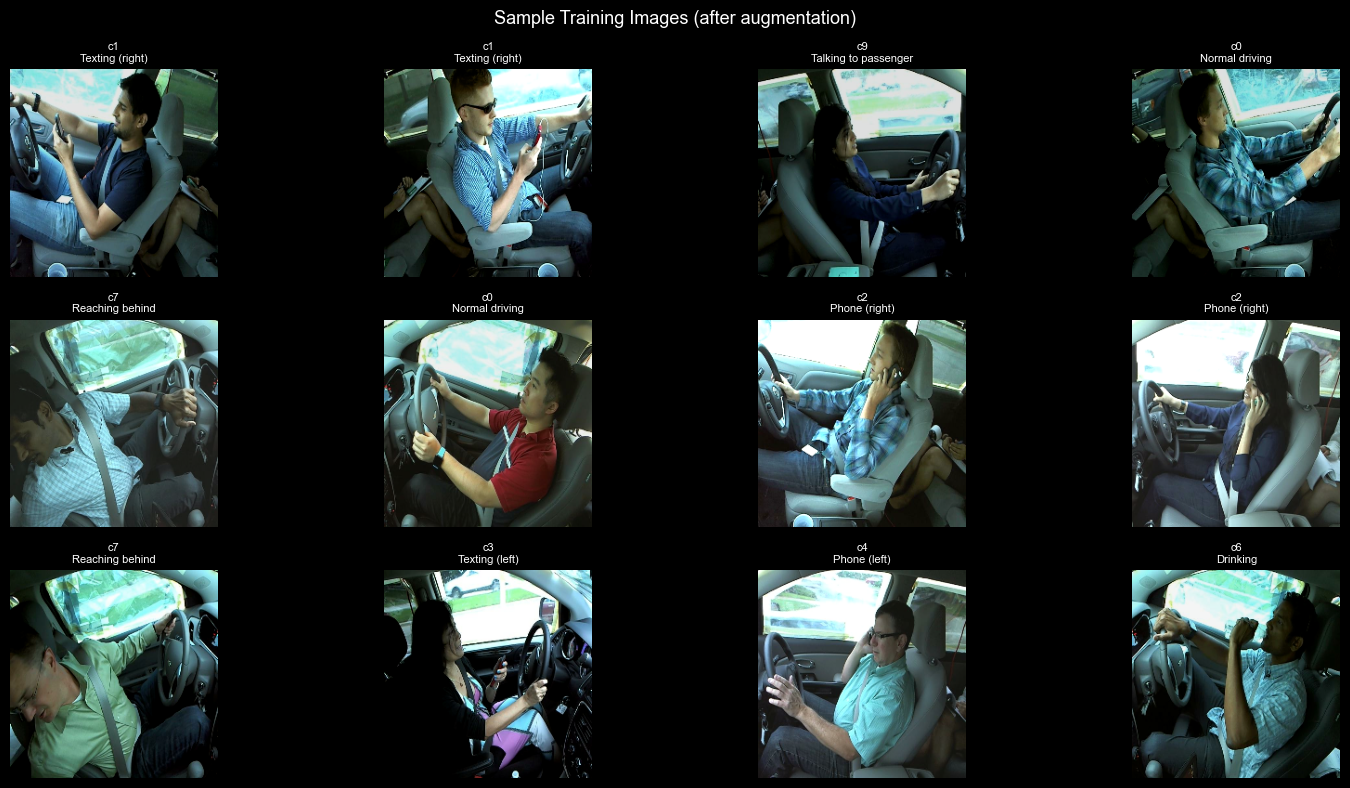

In [25]:
idx2class = {v: k for k, v in label2idx.items()}

images, labels = next(iter(train_ds))
n_show = min(12, BATCH_SIZE)

plt.figure(figsize=(16, 8))
for i in range(n_show):
    plt.subplot(3, 4, i + 1)
    img = images[i].numpy()  # Already in [0,1] range
    cls = idx2class[labels[i].numpy()]
    plt.imshow(img)
    plt.title(f'{cls}\n{CLASS_LABELS[cls]}', fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build Model (EfficientNetB0 Transfer Learning)

In [26]:
def build_model(num_classes=NUM_CLASSES, learning_rate=LEARNING_RATE):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Scale from [0,1] to [0,255] for EfficientNet preprocessing
    x = inputs * 255.0

    # EfficientNetB0: include_top=False, pretrained ImageNet weights
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = False  # Freeze base — Phase 1: train classifier head only

    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_model()
model.summary(line_length=100)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)                 │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ multiply_2 (Multiply)                      │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ efficientnetb0 (Functional)                │ (None, 7, 7, 1280)              │         4,049,571 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 1280)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 1280)                    │             5,120 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 1280)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 256)                     │           327,936 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 10)                      │             2,570 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 5. Phase 1 — Train Classifier Head (Base Frozen)

In [27]:
callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

print('=' * 60)
print('Phase 1: Training classifier head (base frozen)')
print('=' * 60)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1,
)

Phase 1: Training classifier head (base frozen)
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.2500 - loss: 2.5229 - val_accuracy: 0.2900 - val_loss: 2.0854 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.6000 - loss: 1.2377 - val_accuracy: 0.3800 - val_loss: 1.9456 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.7180 - loss: 0.8656 - val_accuracy: 0.4900 - val_loss: 1.7806 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.7520 - loss: 0.7263 - val_accuracy: 0.4400 - val_loss: 1.7239 - learning_rate: 0.0010
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.7740 - loss: 0.6706 - val_accuracy: 0.5100 - val_loss: 1.6411 - learning_rate: 0.0010
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.8480 - loss: 0.4688 - val_accuracy: 0.5200 - val_loss: 1.5767 - learning_rate: 0.0010
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3

## 6. Phase 2 — Fine-tune (Unfreeze Top Layers)

In [28]:
# Unfreeze top 30 layers của EfficientNetB0 để fine-tune
base_model = model.layers[1]   # EfficientNetB0 là layer index 1
base_model.trainable = True

# Chỉ unfreeze 30 layers cuối
for layer in base_model.layers[:-30]:
    layer.trainable = False

total_trainable = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers after unfreeze: {total_trainable}')

# Recompile với LR nhỏ hơn
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
]

print('=' * 60)
print('Phase 2: Fine-tuning top layers')
print('=' * 60)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
)

Trainable layers after unfreeze: 8
Phase 2: Fine-tuning top layers
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6747 - loss: 0.9320
Epoch 1: val_accuracy improved from None to 0.58000, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 348ms/step - accuracy: 0.6820 - loss: 0.9507 - val_accuracy: 0.5800 - val_loss: 1.1576 - learning_rate: 1.0000e-04
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7387 - loss: 0.8110
Epoch 2: val_accuracy improved from 0.58000 to 0.63000, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step - accuracy: 0.7580 - loss: 0.7743 - val_accuracy: 0.6300 - val_loss: 1.0584 - learning_rate: 1.0000e-04
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8183 - loss: 0.5857
Epoch 3: val_accuracy did not improve from 0.63000
16/16 ━━━━━━━━

## 7. Training Curves

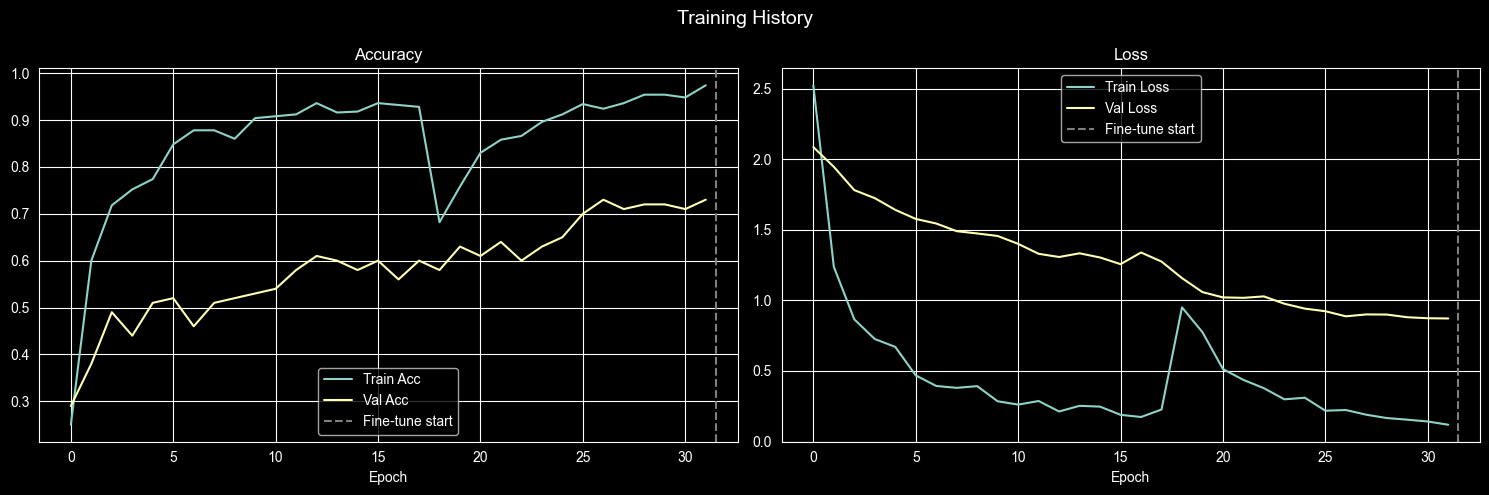

In [29]:
def plot_history(h1, h2=None):
    acc  = h1.history['accuracy']
    vacc = h1.history['val_accuracy']
    loss = h1.history['loss']
    vloss= h1.history['val_loss']

    if h2:
        acc  += h2.history['accuracy']
        vacc += h2.history['val_accuracy']
        loss += h2.history['loss']
        vloss+= h2.history['val_loss']
        phase2_start = len(h1.history['accuracy'])
    else:
        phase2_start = None

    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    axes[0].plot(epochs_range, acc,  label='Train Acc')
    axes[0].plot(epochs_range, vacc, label='Val Acc')
    if phase2_start:
        axes[0].axvline(x=phase2_start - 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs_range, loss,  label='Train Loss')
    axes[1].plot(epochs_range, vloss, label='Val Loss')
    if phase2_start:
        axes[1].axvline(x=phase2_start - 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle('Training History', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

## 8. Evaluate on Validation Set

In [30]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f'Validation Loss     : {val_loss:.4f}')
print(f'Validation Accuracy : {val_acc:.4f} ({val_acc*100:.2f}%)')

Validation Loss     : 0.8871
Validation Accuracy : 0.7300 (73.00%)


## 9. Confusion Matrix & Classification Report

2026-02-25 17:26:32.620161: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


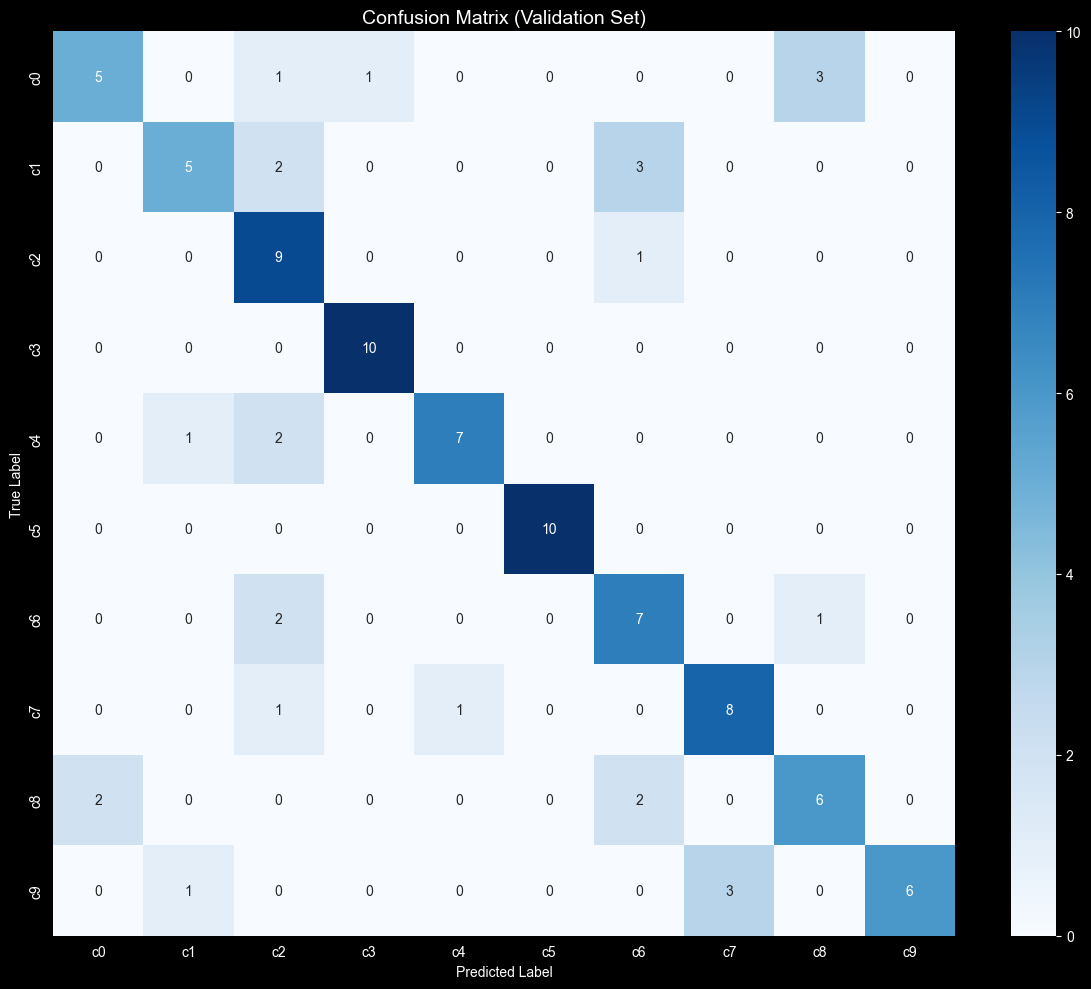


Classification Report:
                      precision    recall  f1-score   support

      Normal driving       0.71      0.50      0.59        10
     Texting (right)       0.71      0.50      0.59        10
       Phone (right)       0.53      0.90      0.67        10
      Texting (left)       0.91      1.00      0.95        10
        Phone (left)       0.88      0.70      0.78        10
               Radio       1.00      1.00      1.00        10
            Drinking       0.54      0.70      0.61        10
     Reaching behind       0.73      0.80      0.76        10
       Hair & makeup       0.60      0.60      0.60        10
Talking to passenger       1.00      0.60      0.75        10

            accuracy                           0.73       100
           macro avg       0.76      0.73      0.73       100
        weighted avg       0.76      0.73      0.73       100



In [31]:
# Lấy toàn bộ predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ─── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Confusion Matrix (Validation Set)', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ─── Classification Report ─────────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(
    y_true, y_pred,
    target_names=[CLASS_LABELS[c] for c in CLASS_NAMES]
))

## 10. Save Final Model

In [32]:
mode_tag = 'sample' if SAMPLE_MODE else 'full'
save_path = os.path.join(MODEL_DIR, f'efficientnetb0_{mode_tag}.keras')
model.save(save_path)
print(f'Model saved to: {save_path}')

# In kết quả tổng kết
print()
print('=' * 50)
print('  SUMMARY')
print('=' * 50)
print(f'  Mode           : {"SAMPLE" if SAMPLE_MODE else "FULL"}')
print(f'  Train images   : {len(train_df)}')
print(f'  Val images     : {len(val_df)}')
print(f'  Val Accuracy   : {val_acc*100:.2f}%')
print(f'  Val Loss       : {val_loss:.4f}')
print(f'  Saved to       : {save_path}')
print('=' * 50)

Model saved to: ../models/efficientnetb0_sample.keras

  SUMMARY
  Mode           : SAMPLE
  Train images   : 500
  Val images     : 100
  Val Accuracy   : 73.00%
  Val Loss       : 0.8871
  Saved to       : ../models/efficientnetb0_sample.keras
